<a href="https://colab.research.google.com/github/vlhsilvia/TRABAJOS-PRACTICOS/blob/Silviamaster/SV_Quanvolutional_Preprocessing_EDP_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="font-size:200px; text-align:center; margin-bottom:0;">
  Quanvolutional4EO
</h1>

<p style="font-size:100px; margin-top:0.25em;">
  This notebook contains all the routines to apply quanvolutional pre-processing to an EO image.
</p>


Install and import dependencies

In [1]:
!pip install pennylane
!pip install hqm --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 75.6 MB/s eta 0:00:00


In [2]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torchvision.datasets import EuroSAT
import pennylane as qml

In [3]:
from pennylane.qnn import TorchLayer

qml.qnn.KerasLayer = TorchLayer

from hqm.circuits.angleencoding import StronglyEntangledCircuit
from hqm.layers.quanvolution import Quanvolution2D

## Define Quantum Circuit

The quantum circuit is used by the quantum convolutional 2D layer. The quantum circuit used in this example has a fixed structure, Ry gates at the beginning, Random Layers U and Z pauli and measurement gates at the end.

```
                                                   _____
                                    |0> ---[Ry]---|     |---[Z]---[m]
                                    |0> ---[Ry]---|     |---[Z]---[m]
                                    |0> ---[Ry]---|  U  |---[Z]---[m]
                                    |0> ---[Ry]---|     |
                                    |0> ..........|_____|
              
```

It is defined by 5 parameters:

1. *QUBITS*: is the number of qubits used, the number is related to the kernel size of convolution. The relation between these two variables is the following:
$$QUBITS \geq KERNEL\_SIZE^2$$

2. *KERNEL_SIZE*: defines the size of the kernel and the number of RY gates
3. *FILTERS*: defines the number of filters produced by the Quantum Convolution
4. *N_LAYERS*: defines the number of U random layers
5. *STRIDE*: defines the stride used for the convolution

## Quantum Convolutional 2D/3D layer

The quantum convolutional 2D/3D layer, uses the quantum circuit define above. As for classical convolution a chuck of the input image of kernel_size dimensions is processed by the quantum circuit that then produces the feature maps. Then as for the classical convolution stride by stride all the chucks of the image are processed.

```
_____________________________________________ Iteration 1 _____________________________________________

                                                                                         Output
                                                                                     ______________
                                                                                    | m3 |    |    |
                                                                                  ______________  _|
        Input Image                                                              | m2 |    |    |  |
    ___________________                                                        ______________  _| _|
   | x1 | x3 |    |    |                                                    __| m1 |    |    |  |  |
   |_|__|_|__|____|____|                                                   |  |____|____|____| _| _|
   | x2 | x4 |    |    |                                                   |  |    |    |    |  |
   |_|__|_|__|____|____|                                                   |  |____|____|____| _|
   | |  | |  |    |    |                                                   |  |    |    |    |
   |_|__|_|__|____|____|                                                   |  |____|____|____|                     
   | |  | |  |    |    |                                                   |
   |_|__|_|__|____|____|                                                   |
     |    |                               Quantum Circuit                  |
     |____|_________________________                            ___________|
                                    |         _____            |
                           |0> ---[Ry(x1)]---|     |---[Z]---[m1]
                           |0> ---[Ry(x2)]---|     |---[Z]---[m2]
                           |0> ---[Ry(x3)]---|  U  |---[Z]---[m3]
                           |0> ---[Ry(x4)]---|_____|


_____________________________________________ Iteration 2 _____________________________________________

                                                                                         Output
                                                                                     ______________
                                                                                    | m3 | m6 |    |
                                                                                  ______________  _|
        Input Image                                                              | m2 | m5 |    |  |
    ___________________                                                        ______________  _| _|
   |    | x3 | x5 |    |                                                    __| m1 | m4 |    |  |  |
   |____|_|__|_|__|____|                                                   |  |____|____|____| _| _|
   |    | x4 | x6 |    |                                                   |  |    |    |    |  |
   |____|_|__|_|__|____|                                                   |  |____|____|____| _|
   |    | |  | |  |    |                                                   |  |    |    |    |
   |____|_|__|_|__|____|                                                   |  |____|____|____|                     
   |    | |  | |  |    |                                                   |
   |____|_|__|_|__|____|                                                   |
          |    |                          Quantum Circuit                  |
          |____|____________________                            ___________|
                                    |         _____            |
                           |0> ---[Ry(x3)]---|     |---[Z]---[m4]
                           |0> ---[Ry(x4)]---|     |---[Z]---[m5]
                           |0> ---[Ry(x5)]---|  U  |---[Z]---[m6]
                           |0> ---[Ry(x6)]---|_____|
              


```


In [4]:
def create_quantum_circuit(n_qubits: int, n_layers: int):
    dev = qml.device("default.qubit", wires=n_qubits)
    return StronglyEntangledCircuit(n_qubits=n_qubits, n_layers=n_layers, dev=dev)

def create_quanv_layer(circuit, filters: int, kernel_size: int, stride: int, padding: str):
    return Quanvolution2D(
        qcircuit=circuit,
        filters=filters,
        kernelsize=kernel_size,
        stride=stride,
        padding=padding
    )


# Parameters
N_QUBITS = 9
N_LAYERS = 1
FILTERS = 9
KERNEL_SIZE = 3
STRIDE = 1
PADDING = 'same'

Load EuroSAT and select first image

100%|██████████| 94.3M/94.3M [00:00<00:00, 211MB/s]


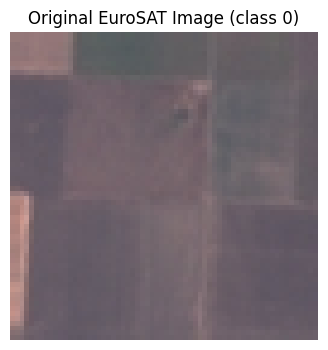

In [5]:
dataset = EuroSAT(root='.', download=True)
img_pil, label = dataset[0]  # first image

# Convert to tensor and add batch dimension
transform = T.Compose([T.ToTensor()])
img = transform(img_pil).unsqueeze(0)  # shape [1, 3, 64, 64]

# Show original image
plt.figure(figsize=(4,4))
plt.title(f"Original EuroSAT Image (class {label})")
plt.imshow(img_pil)
plt.axis('off')
plt.show()

Apply Quanvolution and visualize

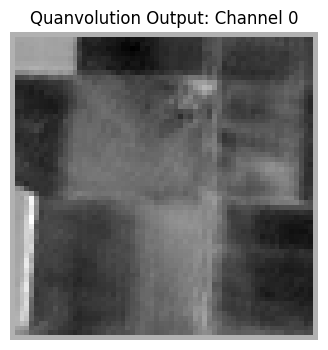

In [6]:
# Build circuit and layer
qc = create_quantum_circuit(N_QUBITS, N_LAYERS)
quanv = create_quanv_layer(qc, FILTERS, KERNEL_SIZE, STRIDE, PADDING)

# Apply quanvolution
with torch.no_grad():
    processed = quanv(img)[0]

# Visualize first processed filter
proc_channel = processed[0].cpu().numpy()
plt.figure(figsize=(4,4))
plt.title("Quanvolution Output: Channel 0")
plt.imshow(proc_channel, cmap='gray')
plt.axis('off')
plt.show()